In [1]:
%matplotlib ipympl
# from stage 1
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# filter
from scipy.signal import butter,filtfilt

# spike detection
from scipy.signal import find_peaks

# PCA
from sklearn.decomposition import PCA

# classifier
# import all packages needed to run the code
from sklearn import metrics
import scipy.interpolate as interp
from sklearn.model_selection import train_test_split

# Imports
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.utils import to_categorical

# Filter Functions

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], analog=False, btype='band')
        y = filtfilt(b, a, data)
        return y

# Load Data

D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

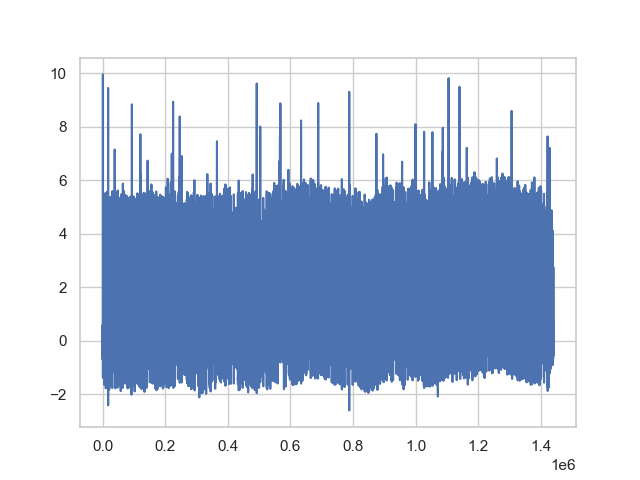

In [3]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

plt.figure(0)
plt.plot(d1)

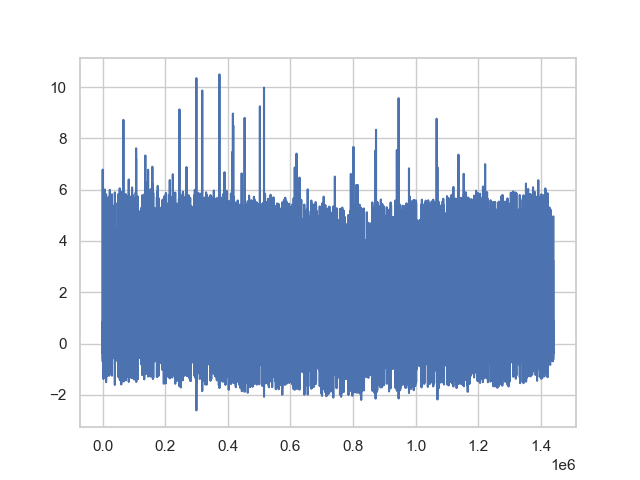

In [4]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']

plt.figure(1)
plt.plot(d2)

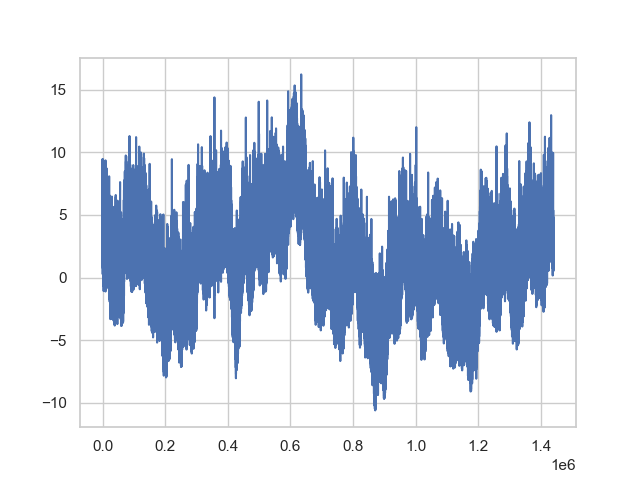

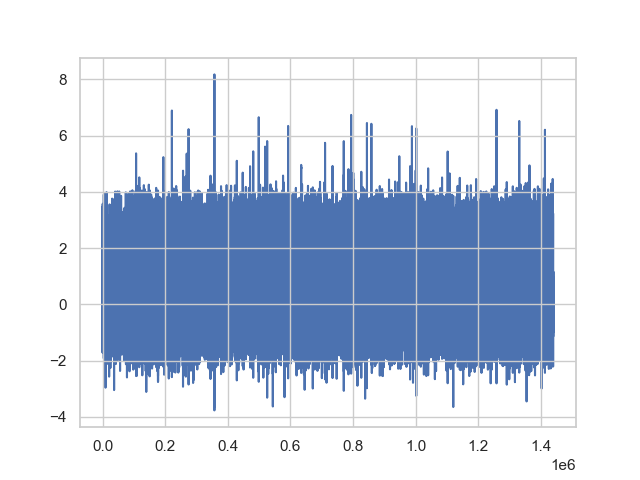

In [5]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

plt.figure(2)
plt.plot(d3)

# Filter requirements.
fs = 25000      # sample rate, Hz
order = 1       # sin wave can be approx represented as quadratic
lowcut = 250 # 300
highcut  = 4050 #3000

d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)
plt.figure(3)
plt.plot(d3_f, zorder=-1)

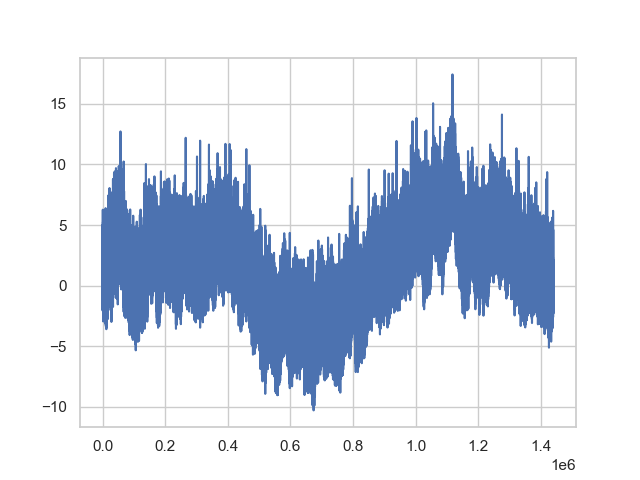

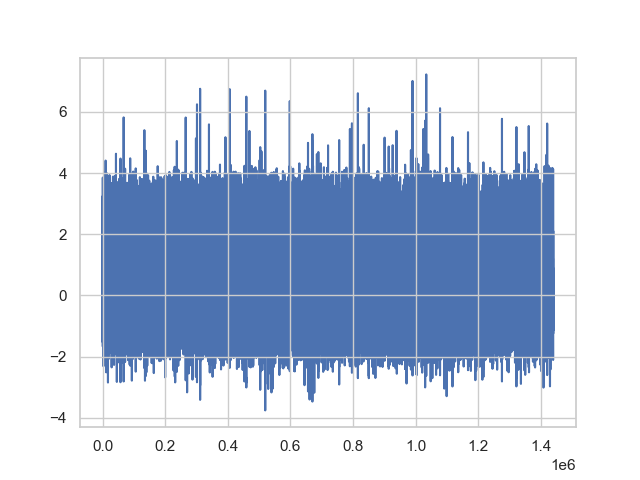

In [6]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

plt.figure(4)
plt.plot(d4)

d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)
plt.figure(5)
plt.plot(d4_f, zorder=-1)

# Spike Detection

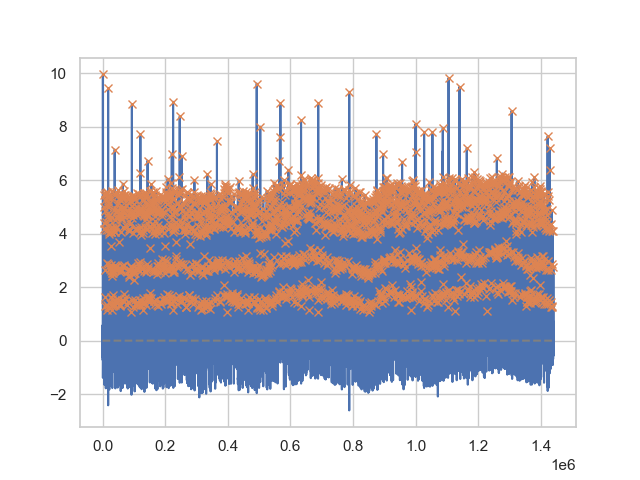

In [7]:
# calculate standard deviation of signal using Donoho's estimation
std = (np.median(abs(d1 - np.mean(d1))/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.5, height = ts)

plt.figure(6)
plt.plot(d1)
plt.plot(peaks1, d1[peaks1], "x")
plt.plot(np.zeros_like(d1), "--", color="gray")
plt.show()

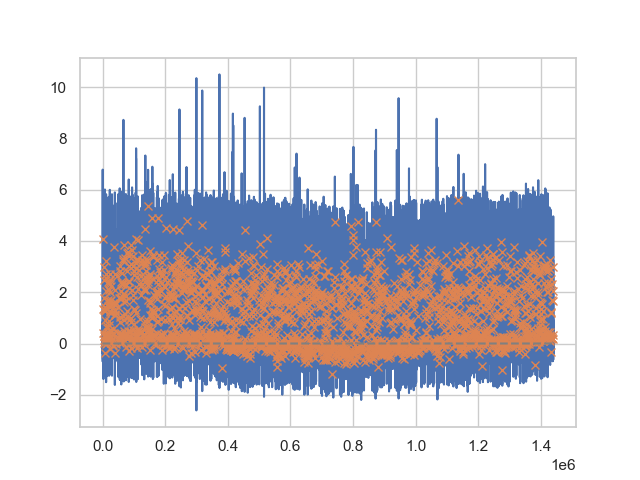

In [8]:
# calculate standard deviation of signal using Donoho's estimation
std2 = (np.median(abs(d2 - np.mean(d2))/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.5, height=ts2)

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10

plt.figure(7)
plt.plot(d2)
plt.plot(Index2, d2[Index2], "x")
plt.plot(np.zeros_like(d2), "--", color="gray")
plt.show()    

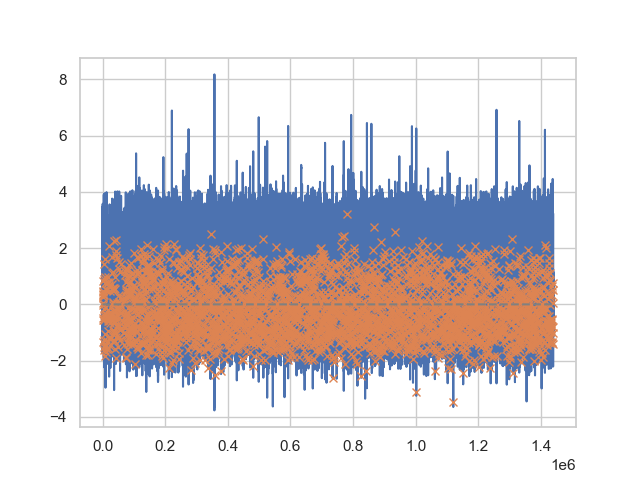

In [9]:
# calculate standard deviation of signal using Donoho's estimation
std3 = (np.median(abs(d3_f - np.mean(d3_f))/0.6745))

# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.5, height=ts3)

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10

plt.figure(8)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.show()  

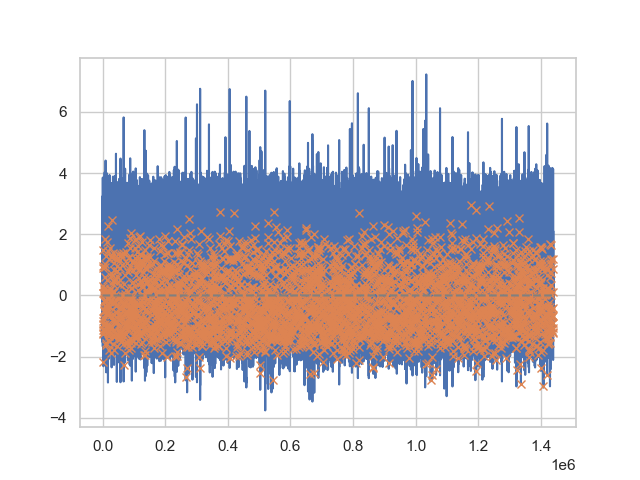

In [10]:
# calculate standard deviation of signal using Donoho's estimation
std4 = (np.median(abs(d4_f - np.mean(d4_f))/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.5, height=ts4)

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10

plt.figure(9)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.show() 

In [11]:
# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Define period of each spike
n_2ms = int((25e3) * 3e-3) # int((25e3)/downsample_factor * 2e-3) # 50 for 25kHz 
if n_2ms%2 != 0:
    n_2ms = n_2ms - 1
n = int(n_2ms/2)
spike = np.zeros([n_2ms,len(Index1)])
spike2 = np.zeros([n_2ms,len(Index2)])
spike3 = np.zeros([n_2ms,len(Index3)])
spike4 = np.zeros([n_2ms,len(Index4)])

# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike[:,k] = d1[i:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike2[:,k] = d2[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike3[:,k] = d3_f[i:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        # spike[:,k] = d1[i-n:i+n]
        spike4[:,k] = d4_f[i:i+n_2ms]
        k = k + 1 

# Dimension Reduction

In [12]:
# training
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.8)].transpose()
d1_spikes_test = spike[:,int(x*0.8):].transpose()
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()
class1_train = Class1_sorted[0:int(x*0.8)]
class1_test = Class1_sorted[int(x*0.8):]

print(d1_spikes_train.shape)
print(d1_spikes_test.shape)
print(d2_spikes_test.shape)
print(d3_spikes_test.shape)
print(d4_spikes_test.shape)

(2202, 74)
(551, 74)
(2330, 74)
(3379, 74)
(3586, 74)


Total Variance Explained:  0.8462251278748056


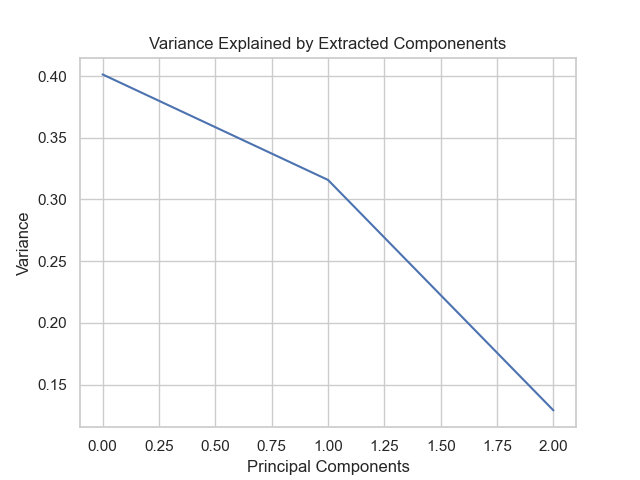

In [13]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)
# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(10)
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Classifier

In [22]:
# Configuration options 
feature_vector_length = len(d1_spikes_train[0])
num_classes = 6

# Reshape the data - MLPs do not understand such things as '2D'.
# Reshape to 28 x 28 pixels = 784 features
X_train = d1_spikes_train #.reshape(d1_spikes_train.shape[0], feature_vector_length)
X_test = d1_spikes_test #.reshape(d1_spikes_test.shape[0], feature_vector_length)

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')
look_back = 1


# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Create the model
model = Sequential()
model.add(LSTM(8, input_shape=(74, 1)))
model.add(Dense(6))

# Configure the model and start training
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=30, batch_size=50, verbose=1, validation_split=0.2)

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

Feature shape: (74,)
Epoch 1/30
36/36 [==============================] - 5s 60ms/step - loss: 2.5270 - accuracy: 0.1902 - val_loss: 2.8598 - val_accuracy: 0.1361
Epoch 2/30
36/36 [==============================] - 2s 49ms/step - loss: 3.3244 - accuracy: 0.2362 - val_loss: 6.7586 - val_accuracy: 0.1995
Epoch 3/30
36/36 [==============================] - 2s 45ms/step - loss: 6.0310 - accuracy: 0.1715 - val_loss: 3.9406 - val_accuracy: 0.1837
Epoch 4/30
36/36 [==============================] - 2s 49ms/step - loss: 7.5152 - accuracy: 0.1709 - val_loss: 10.9032 - val_accuracy: 0.1859
Epoch 5/30
36/36 [==============================] - 2s 49ms/step - loss: 11.4124 - accuracy: 0.1715 - val_loss: 11.1040 - val_accuracy: 0.1859
Epoch 6/30
36/36 [==============================] - 2s 45ms/step - loss: 10.7902 - accuracy: 0.1715 - val_loss: 9.6308 - val_accuracy: 0.1859
Epoch 7/30
36/36 [==============================] - 2s 44ms/step - loss: 7.4033 - accuracy: 0.1721 - val_loss: 6.6622 - val_accur

KeyboardInterrupt: 

In [ ]:
class2_out = model.predict(d2_spikes_test)
Class2 = np.zeros(len(class2_out))
i = 0
for l in class2_out:
    Class2[i] = l.argmax()
    i = i + 1


In [ ]:
class3_out = model.predict(d3_spikes_test)
Class3 = np.zeros(len(class3_out))
i = 0
for l in class3_out:
    Class3[i] = l.argmax()
    i = i + 1

In [ ]:
class4_out = model.predict(d4_spikes_test)
Class4 = np.zeros(len(class4_out))
i = 0
for l in class4_out:
    Class4[i] = l.argmax()
    i = i + 1

In [ ]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)
# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

In [ ]:
# Configuration options 
feature_vector_length = pca_num
num_classes = 6

# Reshape the data 
X_train = train_ext 
X_test = test_ext 

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')
look_back = 1

# Create the model
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))

# Configure the model and start training
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=100, batch_size=4, verbose=1, validation_split=0.2)

# Test the model after training
test_results = model.evaluate(X_test, Y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]}%')

Feature shape: (3,)
Epoch 1/100
441/441 [==============================] - 4s 6ms/step - loss: 0.4318 - accuracy: 0.8966 - val_loss: 0.3235 - val_accuracy: 0.9274
Epoch 2/100
441/441 [==============================] - 1s 3ms/step - loss: 0.2348 - accuracy: 0.9512 - val_loss: 0.2995 - val_accuracy: 0.9342
Epoch 3/100
441/441 [==============================] - 1s 3ms/step - loss: 0.2122 - accuracy: 0.9506 - val_loss: 0.2873 - val_accuracy: 0.9365
Epoch 4/100
441/441 [==============================] - 1s 3ms/step - loss: 0.1857 - accuracy: 0.9557 - val_loss: 0.2725 - val_accuracy: 0.9410
Epoch 5/100
441/441 [==============================] - 1s 3ms/step - loss: 0.1729 - accuracy: 0.9574 - val_loss: 0.2531 - val_accuracy: 0.9365
Epoch 6/100
441/441 [==============================] - 1s 3ms/step - loss: 0.1653 - accuracy: 0.9597 - val_loss: 0.2650 - val_accuracy: 0.9320
Epoch 7/100
441/441 [==============================] - 1s 3ms/step - loss: 0.1579 - accuracy: 0.9585 - val_loss: 0.3444 - 